# **imports**

In [21]:
from datasets import load_dataset
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# **carregar dataset**

In [22]:
DATASET_NAME = "chronopt-research/cropped-vggface2-224"

dataset = load_dataset(DATASET_NAME)
dataset

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/40 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 3138862
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 169178
    })
})

# **mostrar os splits disponíveis**

In [23]:
print(dataset)
print("\nSplits disponíveis:", list(dataset.keys()))

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 3138862
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 169178
    })
})

Splits disponíveis: ['train', 'validation']


# **ver colunas do split train**

In [24]:
dataset["train"].column_names

['image', 'label']

# **ver um exemplo bruto**

In [25]:
dataset["train"][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224>,
 'label': 1}

# **visualizar a primeira imagem**

Label: 1


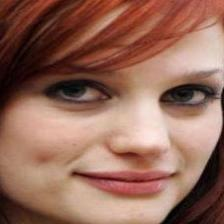

In [26]:
sample = dataset["train"][0]

print("Label:", sample["label"])
display(sample["image"])

# **verificar quantidade total de exemplos por split**

In [27]:
for split_name in dataset.keys():
    print(f"{split_name}: {len(dataset[split_name])} exemplos")

train: 3138862 exemplos
validation: 169178 exemplos


## **contar quantas classes existem no train**



In [28]:
labels = dataset["train"]["label"]
label_counts = Counter(labels)

num_classes = len(label_counts)
print("Número de classes no train:", num_classes)

Número de classes no train: 8631


# **transformar contagem em DataFrame**

In [29]:
df_balance = pd.DataFrame(
    [{"label": label, "num_images": count} for label, count in label_counts.items()]
).sort_values("num_images", ascending=False)

df_balance.head(20)

,label,num_images
768,801,842
4473,4740,808
1492,1566,757
7738,8191,746
254,266,719
2565,2712,711
3990,4214,699
4308,4555,698
4736,5018,694
398,414,689


# **estatísticas de balanceamento**

In [30]:
print("Resumo do número de imagens por classe:")
print(df_balance["num_images"].describe())

Resumo do número de imagens por classe:
count    8631.000000
mean      363.673039
std       101.222069
min        87.000000
25%       292.000000
50%       359.000000
75%       432.000000
max       842.000000
Name: num_images, dtype: float64


# **diagnóstico simples do balanceamento**

In [31]:
min_imgs = df_balance["num_images"].min()
max_imgs = df_balance["num_images"].max()
mean_imgs = df_balance["num_images"].mean()
median_imgs = df_balance["num_images"].median()

print("Classes:", len(df_balance))
print("Mínimo de imagens por classe:", min_imgs)
print("Máximo de imagens por classe:", max_imgs)
print("Média de imagens por classe:", mean_imgs)
print("Mediana de imagens por classe:", median_imgs)

if min_imgs == max_imgs:
    print("Dataset perfeitamente balanceado.")
else:
    print("Dataset NÃO é perfeitamente balanceado.")

Classes: 8631
Mínimo de imagens por classe: 87
Máximo de imagens por classe: 842
Média de imagens por classe: 363.67303904530183
Mediana de imagens por classe: 359.0
Dataset NÃO é perfeitamente balanceado.


# **ver classes com mais imagens**

In [32]:
print("Top 20 classes com mais imagens:")
display(df_balance.head(20))

Top 20 classes com mais imagens:


,label,num_images
768,801,842
4473,4740,808
1492,1566,757
7738,8191,746
254,266,719
2565,2712,711
3990,4214,699
4308,4555,698
4736,5018,694
398,414,689


# **ver classes com menos imagens**

In [33]:
print("Top 20 classes com menos imagens:")
display(df_balance.tail(20))

Top 20 classes com menos imagens:


,label,num_images
7192,7618,117
2896,3068,117
3331,3524,116
4820,5119,115
6980,7396,113
6257,6642,113
2994,3170,113
238,249,112
2847,3015,110
7873,8328,108


# **histograma da distribuição**

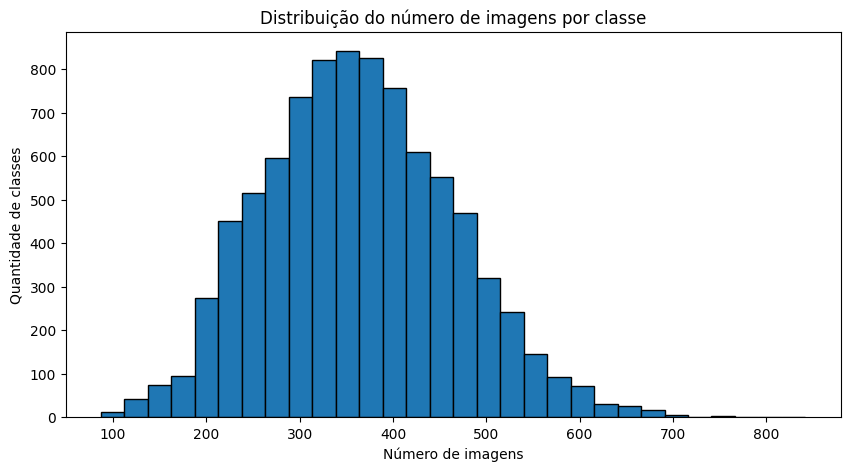

In [34]:
plt.figure(figsize=(10, 5))
plt.hist(df_balance["num_images"], bins=30, edgecolor="black")
plt.title("Distribuição do número de imagens por classe")
plt.xlabel("Número de imagens")
plt.ylabel("Quantidade de classes")
plt.show()

# **filtrar classes com quantidade mínima de imagens**

In [35]:
MIN_IMAGES_PER_CLASS = 80

selected_labels = df_balance[
    df_balance["num_images"] >= MIN_IMAGES_PER_CLASS
]["label"].tolist()

print("Número de classes com pelo menos", MIN_IMAGES_PER_CLASS, "imagens:", len(selected_labels))

Número de classes com pelo menos 80 imagens: 8631


# **criar subconjunto filtrado**

In [36]:
filtered_train = dataset["train"].filter(lambda x: x["label"] in selected_labels)

print(filtered_train)

Dataset({
    features: ['image', 'label'],
    num_rows: 3138862
})


# **amostrar só algumas classes para treino mais leve**

In [37]:
NUM_CLASSES_TO_USE = 50

selected_subset_labels = df_balance[
    df_balance["num_images"] >= MIN_IMAGES_PER_CLASS
].sample(n=NUM_CLASSES_TO_USE, random_state=42)["label"].tolist()

subset_train = dataset["train"].filter(lambda x: x["label"] in selected_subset_labels)

print(subset_train)
print("Classes selecionadas:", len(set(subset_train["label"])))

Dataset({
    features: ['image', 'label'],
    num_rows: 18267
})
Classes selecionadas: 50


# **verificar balanceamento do subconjunto**

In [38]:
subset_counts = Counter(subset_train["label"])

df_subset_balance = pd.DataFrame(
    [{"label": label, "num_images": count} for label, count in subset_counts.items()]
).sort_values("num_images", ascending=False)

display(df_subset_balance.head(20))
print(df_subset_balance["num_images"].describe())

,label,num_images
46,8083,501
14,3110,497
39,6779,495
21,3668,484
49,8801,484
3,1270,484
11,2641,482
0,232,479
17,3287,466
48,8606,465


count     50.000000
mean     365.340000
std       92.935046
min      139.000000
25%      312.000000
50%      367.500000
75%      444.500000
max      501.000000
Name: num_images, dtype: float64


# **visualizar algumas imagens aleatórias do subconjunto**

Label: 4212


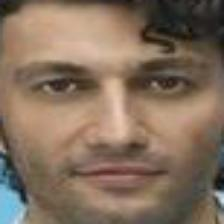

Label: 1417


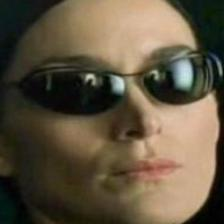

Label: 6749


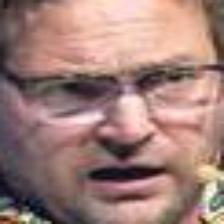

Label: 7988


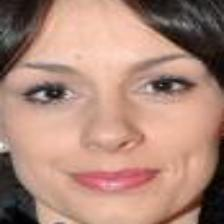

Label: 3287


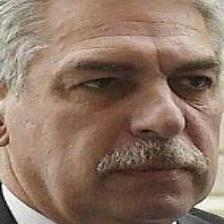

In [39]:
import random

indices = random.sample(range(len(subset_train)), 5)

for idx in indices:
    item = subset_train[idx]
    print("Label:", item["label"])
    display(item["image"])

# **Continuação do notebook - Parte do Modelo**

#  

# **1. instalar dependências**

In [41]:
!pip install insightface onnxruntime-gpu

# **2. imports**

In [42]:
import os
import cv2
import time
import random
import itertools
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import defaultdict, Counter

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import torch
import onnxruntime as ort

from insightface.app import FaceAnalysis
from insightface.model_zoo import get_model

# 3. SEED


In [43]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


# 4. CHECAGEM DE GPU


In [44]:
print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Providers ORT:", ort.get_available_providers())


CUDA disponível: True
GPU: Tesla T4
Providers ORT: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


# 5. CONFIGURAÇÃO DA AMOSTRA CONTROLADA


In [45]:
MAX_CLASSES = 20
IMAGES_PER_CLASS = 6


# 6. REDUZIR O subset_train PARA UMA AMOSTRA CONTROLADA


In [46]:
items_by_label = defaultdict(list)

for idx in range(len(subset_train)):
    item = subset_train[idx]
    items_by_label[item["label"]].append(idx)

top_labels = sorted(
    items_by_label.keys(),
    key=lambda label: len(items_by_label[label]),
    reverse=True
)[:MAX_CLASSES]

selected_indices = []

for label in top_labels:
    selected_indices.extend(items_by_label[label][:IMAGES_PER_CLASS])

subset_small = subset_train.select(selected_indices)

print("Classes escolhidas:", len(top_labels))
print("Total de imagens no subset reduzido:", len(subset_small))
print("Labels escolhidos:", top_labels[:10], "..." if len(top_labels) > 10 else "")

Classes escolhidas: 20
Total de imagens no subset reduzido: 120
Labels escolhidos: [8083, 3110, 6779, 1270, 3668, 8801, 2641, 232, 3287, 8606] ...


# 7. CARREGAR MODELO DE EMBEDDING


In [47]:
ctx_id = 0 if torch.cuda.is_available() else -1
print("ctx_id usado:", ctx_id)

# força download do pacote buffalo_l
face_app = FaceAnalysis(name="buffalo_l")
face_app.prepare(ctx_id=ctx_id, det_size=(640, 640))

model_path = os.path.expanduser("~/.insightface/models/buffalo_l/w600k_r50.onnx")
print("Model path:", model_path)
print("Arquivo existe?", os.path.exists(model_path))

rec_model = get_model(model_path)
rec_model.prepare(ctx_id=ctx_id)

print("Modelo de embedding carregado com sucesso.")


ctx_id usado: 0
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 86550.10KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

# 8. FUNÇÃO DE EXTRAÇÃO DE EMBEDDING


In [48]:
def extract_embedding_from_cropped_face(pil_image):
    image = np.array(pil_image)

    if image.ndim == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    image = cv2.resize(image, (112, 112))

    embedding = rec_model.get_feat(image).flatten()
    embedding = embedding / np.linalg.norm(embedding)

    return embedding.astype(np.float32)


# 9. EXTRAIR EMBEDDINGS


In [49]:
embeddings_data = []

start_embeddings = time.time()

for idx in tqdm(range(len(subset_small))):
    item = subset_small[idx]
    image = item["image"]
    label = item["label"]

    try:
        embedding = extract_embedding_from_cropped_face(image)

        embeddings_data.append({
            "index": idx,
            "label": label,
            "embedding": embedding
        })
    except Exception:
        continue

end_embeddings = time.time()

print("Total original subset_small:", len(subset_small))
print("Total com embedding válido :", len(embeddings_data))
print(f"Tempo total da extração: {(end_embeddings - start_embeddings):.2f} s")
print(f"Tempo médio por imagem : {((end_embeddings - start_embeddings) / max(len(subset_small),1)) * 1000:.2f} ms")

# opcional: salvar embeddings para não recalcular depois
os.makedirs("modelos", exist_ok=True)
joblib.dump(embeddings_data, "modelos/embeddings_data_small.pkl")
print("Embeddings salvos em modelos/embeddings_data_small.pkl")

100%|██████████| 120/120 [00:02<00:00, 46.98it/s]

Total original subset_small: 120
Total com embedding válido : 120
Tempo total da extração: 2.56 s
Tempo médio por imagem : 21.37 ms
Embeddings salvos em modelos/embeddings_data_small.pkl


# 10. ORGANIZAR EMBEDDINGS POR CLASSE


In [50]:
embeddings_by_label = defaultdict(list)

for item in embeddings_data:
    embeddings_by_label[item["label"]].append(item["embedding"])

label_counts = {label: len(embs) for label, embs in embeddings_by_label.items()}
print("Quantidade por classe:")
print(label_counts)

# manter só classes com pelo menos 4 embeddings válidos
valid_labels = [label for label, embs in embeddings_by_label.items() if len(embs) >= 4]

filtered_embeddings_by_label = {
    label: embeddings_by_label[label]
    for label in valid_labels
}

print("Número de classes válidas:", len(filtered_embeddings_by_label))
print("Classes válidas:", list(filtered_embeddings_by_label.keys()))


Quantidade por classe:
{8083: 6, 3110: 6, 6779: 6, 1270: 6, 3668: 6, 8801: 6, 2641: 6, 232: 6, 3287: 6, 8606: 6, 7710: 6, 2856: 6, 4212: 6, 2377: 6, 1417: 6, 3710: 6, 3123: 6, 2304: 6, 6892: 6, 6016: 6}
Número de classes válidas: 20
Classes válidas: [8083, 3110, 6779, 1270, 3668, 8801, 2641, 232, 3287, 8606, 7710, 2856, 4212, 2377, 1417, 3710, 3123, 2304, 6892, 6016]


# 11. SPLIT CORRETO ANTES DOS PARES


In [51]:
train_embeddings = defaultdict(list)
test_embeddings = defaultdict(list)

for label, embs in filtered_embeddings_by_label.items():
    idxs = list(range(len(embs)))

    train_idx, test_idx = train_test_split(
        idxs,
        test_size=0.33,   # com 6 imgs/classe → 4 treino, 2 teste aproximadamente
        random_state=SEED
    )

    for i in train_idx:
        train_embeddings[label].append(embs[i])

    for i in test_idx:
        test_embeddings[label].append(embs[i])

print("Classes no treino:", len(train_embeddings))
print("Classes no teste :", len(test_embeddings))


Classes no treino: 20
Classes no teste : 20


# 12. FUNÇÕES DE SIMILARIDADE E FEATURES


In [52]:
def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def pair_features(emb1, emb2):
    cos_sim = cosine_similarity(emb1, emb2)
    l2_dist = float(np.linalg.norm(emb1 - emb2))
    abs_diff = np.abs(emb1 - emb2)

    return [
        cos_sim,
        l2_dist,
        float(np.mean(abs_diff)),
        float(np.max(abs_diff)),
        float(np.min(abs_diff)),
        float(np.std(abs_diff))
    ]

# 13. GERAR PARES


In [53]:
def generate_pairs(embeddings_dict, random_state=42):
    rng = random.Random(random_state)
    labels = list(embeddings_dict.keys())

    positive_pairs = []
    negative_pairs = []

    # positivos
    for label, embs in embeddings_dict.items():
        if len(embs) < 2:
            continue

        for emb1, emb2 in itertools.combinations(embs, 2):
            positive_pairs.append({
                "features": pair_features(emb1, emb2),
                "target": 1,
                "cos_sim": cosine_similarity(emb1, emb2)
            })

    # negativos balanceados
    target_negatives = len(positive_pairs)

    while len(negative_pairs) < target_negatives:
        label1, label2 = rng.sample(labels, 2)

        emb1 = rng.choice(embeddings_dict[label1])
        emb2 = rng.choice(embeddings_dict[label2])

        negative_pairs.append({
            "features": pair_features(emb1, emb2),
            "target": 0,
            "cos_sim": cosine_similarity(emb1, emb2)
        })

    pairs = positive_pairs + negative_pairs
    rng.shuffle(pairs)

    X = np.array([p["features"] for p in pairs], dtype=np.float32)
    y = np.array([p["target"] for p in pairs], dtype=np.int32)
    sims = np.array([p["cos_sim"] for p in pairs], dtype=np.float32)

    return X, y, sims

X_train, y_train, sims_train = generate_pairs(train_embeddings, random_state=SEED)
X_test, y_test, sims_test = generate_pairs(test_embeddings, random_state=SEED + 1)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)
print("Distribuição treino:", Counter(y_train))
print("Distribuição teste :", Counter(y_test))


X_train: (240, 6) y_train: (240,)
X_test : (40, 6) y_test : (40,)
Distribuição treino: Counter({np.int32(1): 120, np.int32(0): 120})
Distribuição teste : Counter({np.int32(0): 20, np.int32(1): 20})


# 14. FUNÇÕES DE MÉTRICAS


In [54]:
def compute_main_metrics(y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score)
    return acc, prec, rec, f1, auc

def compute_eer_and_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    eer_threshold = thresholds[eer_idx]
    return eer, eer_threshold, fpr, tpr, thresholds

def evaluate_threshold(y_true, y_score, threshold):
    y_thr = (y_score >= threshold).astype(int)

    acc = accuracy_score(y_true, y_thr)
    prec = precision_score(y_true, y_thr, zero_division=0)
    rec = recall_score(y_true, y_thr, zero_division=0)
    f1 = f1_score(y_true, y_thr, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_thr).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "far": float(far),
        "frr": float(frr),
        "confusion_matrix": np.array([[tn, fp], [fn, tp]])
    }

def find_best_f1_threshold(y_true, y_score, thresholds):
    best = None
    best_f1 = -1
    for thr in thresholds:
        metrics = evaluate_threshold(y_true, y_score, thr)
        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best = metrics
    return best

def find_strict_threshold(y_true, y_score, thresholds, max_far=0.05):
    candidates = []
    for thr in thresholds:
        metrics = evaluate_threshold(y_true, y_score, thr)
        if metrics["far"] <= max_far:
            candidates.append(metrics)
    if not candidates:
        return None
    candidates = sorted(candidates, key=lambda x: (x["recall"], x["f1"]), reverse=True)
    return candidates[0]

def find_sensitive_threshold(y_true, y_score, thresholds, max_frr=0.10):
    candidates = []
    for thr in thresholds:
        metrics = evaluate_threshold(y_true, y_score, thr)
        if metrics["frr"] <= max_frr:
            candidates.append(metrics)
    if not candidates:
        return None
    candidates = sorted(candidates, key=lambda x: (x["precision"], x["f1"]), reverse=True)
    return candidates[0]

# 15. BASELINE — SIMILARIDADE PURA


In [55]:
print("\n===== BASELINE: SIMILARIDADE PURA =====")

sim_auc = roc_auc_score(y_test, sims_test)
eer_sim, eer_thr_sim, fpr_sim, tpr_sim, thresholds_sim = compute_eer_and_threshold(y_test, sims_test)
best_f1_sim = find_best_f1_threshold(y_test, sims_test, thresholds_sim)
strict_sim = find_strict_threshold(y_test, sims_test, thresholds_sim, max_far=0.05)
sensitive_sim = find_sensitive_threshold(y_test, sims_test, thresholds_sim, max_frr=0.10)

print(f"ROC-AUC (similaridade): {sim_auc:.4f}")
print(f"EER (similaridade)    : {eer_sim:.4f}")
print("Balanceado:", best_f1_sim)
print("Estrito   :", strict_sim)
print("Sensível  :", sensitive_sim)


===== BASELINE: SIMILARIDADE PURA =====
ROC-AUC (similaridade): 0.9975
EER (similaridade)    : 0.0500
Balanceado: {'threshold': 0.17129197716712952, 'accuracy': 0.975, 'precision': 0.9523809523809523, 'recall': 1.0, 'f1': 0.975609756097561, 'far': 0.05, 'frr': 0.0, 'confusion_matrix': array([[19,  1],
       [ 0, 20]])}
Estrito   : {'threshold': 0.17129197716712952, 'accuracy': 0.975, 'precision': 0.9523809523809523, 'recall': 1.0, 'f1': 0.975609756097561, 'far': 0.05, 'frr': 0.0, 'confusion_matrix': array([[19,  1],
       [ 0, 20]])}
Sensível  : {'threshold': 0.26165661215782166, 'accuracy': 0.975, 'precision': 1.0, 'recall': 0.95, 'f1': 0.9743589743589743, 'far': 0.0, 'frr': 0.05, 'confusion_matrix': array([[20,  0],
       [ 1, 19]])}


# 16. MODELO FINAL — LOGISTIC REGRESSION


In [56]:
print("\n===== MODELO: LOGISTIC REGRESSION =====")

clf = LogisticRegression(
    random_state=SEED,
    max_iter=1000,
    class_weight="balanced"
)

start_train = time.time()
clf.fit(X_train, y_train)
end_train = time.time()

print(f"Tempo de treino: {end_train - start_train:.2f} s")

start_inf = time.time()
y_score = clf.predict_proba(X_test)[:, 1]
y_pred = (y_score >= 0.5).astype(int)
end_inf = time.time()

avg_inf_ms = ((end_inf - start_inf) / len(X_test)) * 1000

acc, prec, rec, f1, auc = compute_main_metrics(y_test, y_pred, y_score)
eer, eer_thr, fpr, tpr, thresholds = compute_eer_and_threshold(y_test, y_score)
best_f1_metrics = find_best_f1_threshold(y_test, y_score, thresholds)
strict_metrics = find_strict_threshold(y_test, y_score, thresholds, max_far=0.05)
sensitive_metrics = find_sensitive_threshold(y_test, y_score, thresholds, max_frr=0.10)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print(f"EER      : {eer:.4f}")
print(f"Latência : {avg_inf_ms:.4f} ms/par")



===== MODELO: LOGISTIC REGRESSION =====
Tempo de treino: 0.05 s
Accuracy : 0.9250
Precision: 1.0000
Recall   : 0.8500
F1-score : 0.9189
ROC-AUC  : 0.9975
EER      : 0.0500
Latência : 0.0151 ms/par


# 17. RESULTADO FINAL


In [57]:
print("\n===== THRESHOLD OPERACIONAL: BALANCEADO =====")
print(best_f1_metrics)

print("\n===== THRESHOLD OPERACIONAL: ESTRITO =====")
print(strict_metrics)

print("\n===== THRESHOLD OPERACIONAL: SENSÍVEL =====")
print(sensitive_metrics)


===== THRESHOLD OPERACIONAL: BALANCEADO =====
{'threshold': 0.3046876285366574, 'accuracy': 0.975, 'precision': 0.9523809523809523, 'recall': 1.0, 'f1': 0.975609756097561, 'far': 0.05, 'frr': 0.0, 'confusion_matrix': array([[19,  1],
       [ 0, 20]])}

===== THRESHOLD OPERACIONAL: ESTRITO =====
{'threshold': 0.3046876285366574, 'accuracy': 0.975, 'precision': 0.9523809523809523, 'recall': 1.0, 'f1': 0.975609756097561, 'far': 0.05, 'frr': 0.0, 'confusion_matrix': array([[19,  1],
       [ 0, 20]])}

===== THRESHOLD OPERACIONAL: SENSÍVEL =====
{'threshold': 0.4647465018601573, 'accuracy': 0.975, 'precision': 1.0, 'recall': 0.95, 'f1': 0.9743589743589743, 'far': 0.0, 'frr': 0.05, 'confusion_matrix': array([[20,  0],
       [ 1, 19]])}


# 18. MATRIZ DE CONFUSÃO DO THRESHOLD BALANCEADO


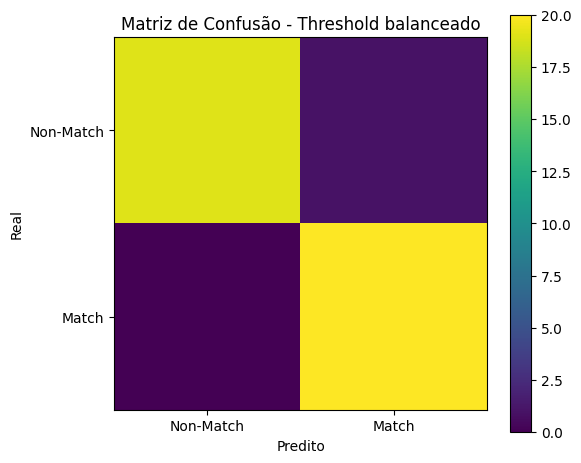

Matriz de confusão:
[[19  1]
 [ 0 20]]


In [58]:
balanced_thr = best_f1_metrics["threshold"]
balanced_pred = (y_score >= balanced_thr).astype(int)
cm = confusion_matrix(y_test, balanced_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de Confusão - Threshold balanceado")
plt.colorbar()
plt.xticks([0, 1], ["Non-Match", "Match"])
plt.yticks([0, 1], ["Non-Match", "Match"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

print("Matriz de confusão:")
print(cm)

# 19. CURVA ROC


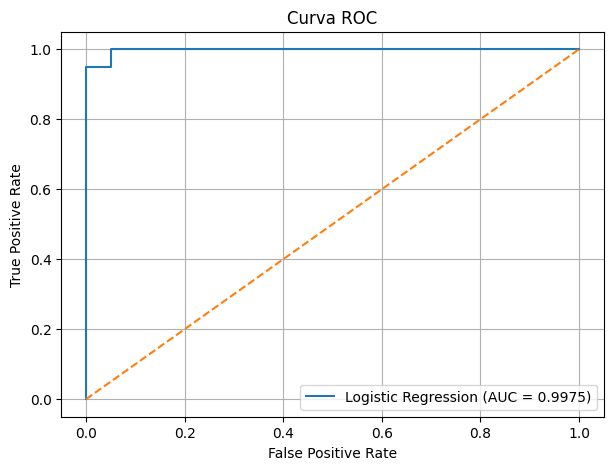

In [59]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()

# 20. BASELINE VS MODELO


In [60]:
comparison_df = pd.DataFrame([
    {
        "Método": "Similaridade pura",
        "ROC-AUC": sim_auc,
        "EER": eer_sim,
        "Threshold balanceado": best_f1_sim["threshold"],
        "F1 balanceado": best_f1_sim["f1"],
        "FAR balanceado": best_f1_sim["far"],
        "FRR balanceado": best_f1_sim["frr"]
    },
    {
        "Método": "LogisticRegression",
        "ROC-AUC": auc,
        "EER": eer,
        "Threshold balanceado": best_f1_metrics["threshold"],
        "F1 balanceado": best_f1_metrics["f1"],
        "FAR balanceado": best_f1_metrics["far"],
        "FRR balanceado": best_f1_metrics["frr"]
    }
])

print("\n===== BASELINE VS MODELO FINAL =====")
display(comparison_df)


===== BASELINE VS MODELO FINAL =====


,Método,ROC-AUC,EER,Threshold balanceado,F1 balanceado,FAR balanceado,FRR balanceado
0,Similaridade pura,0.9975,0.05,0.171292,0.97561,0.05,0.0
1,LogisticRegression,0.9975,0.05,0.304688,0.97561,0.05,0.0


# 21. CLASSIFICATION REPORT


In [61]:
print("===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, balanced_pred, zero_division=0))


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.95      1.00      0.98        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



# 22. RESUMO FINAL


In [62]:
summary_df = pd.DataFrame([{
    "Modelo final": "LogisticRegression",
    "Accuracy default": acc,
    "Precision default": prec,
    "Recall default": rec,
    "F1 default": f1,
    "ROC-AUC": auc,
    "EER": eer,
    "Threshold balanceado": best_f1_metrics["threshold"],
    "F1 balanceado": best_f1_metrics["f1"],
    "FAR balanceado": best_f1_metrics["far"],
    "FRR balanceado": best_f1_metrics["frr"],
    "Threshold estrito": None if strict_metrics is None else strict_metrics["threshold"],
    "FAR estrito": None if strict_metrics is None else strict_metrics["far"],
    "FRR estrito": None if strict_metrics is None else strict_metrics["frr"],
    "Threshold sensível": None if sensitive_metrics is None else sensitive_metrics["threshold"],
    "FAR sensível": None if sensitive_metrics is None else sensitive_metrics["far"],
    "FRR sensível": None if sensitive_metrics is None else sensitive_metrics["frr"],
    "Latência classificador (ms/par)": avg_inf_ms,
    "Tempo médio embedding (ms/img)": ((end_embeddings - start_embeddings) / max(len(subset_small),1)) * 1000
}])

print("===== RESUMO FINAL =====")
display(summary_df)

===== RESUMO FINAL =====


,Modelo final,Accuracy default,Precision default,Recall default,F1 default,ROC-AUC,EER,Threshold balanceado,F1 balanceado,FAR balanceado,FRR balanceado,Threshold estrito,FAR estrito,FRR estrito,Threshold sensível,FAR sensível,FRR sensível,Latência classificador (ms/par),Tempo médio embedding (ms/img)
0,LogisticRegression,0.925,1.0,0.85,0.918919,0.9975,0.05,0.304688,0.97561,0.05,0.0,0.304688,0.05,0.0,0.464747,0.0,0.05,0.015068,21.365456


# 23. SALVAR MODELO FINAL


In [63]:
joblib.dump({
    "model_name": "LogisticRegression",
    "classifier": clf,
    "threshold_balanceado": best_f1_metrics["threshold"],
    "threshold_estrito": None if strict_metrics is None else strict_metrics["threshold"],
    "threshold_sensivel": None if sensitive_metrics is None else sensitive_metrics["threshold"]
}, "modelos/classificador_match_embeddings_final.pkl")

print("Modelo salvo em modelos/classificador_match_embeddings_final.pkl")

Modelo salvo em modelos/classificador_match_embeddings_final.pkl


# 24. DOWNLOAD DO MODELO FINAL


In [65]:
from google.colab import files
files.download("modelos/classificador_match_embeddings_final.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>